# Лабораторная работа №2.2
## *AED*
по курсу Анализ Акустических событий  
**направление:** Речевые технологии и машинное обучение  
**преподаватель:** Шуранов Евгений Виитальевич
**выполнили:** Иванова Мария Кирилловна
**группа:** М4121

### Вариант 5.
### MFCC + Naive Bayes 

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import librosa
import os
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score 


In [11]:
# Загрузка файла
audio_dir = 'audio_train/train/'
df = pd.read_csv('train.csv')
df.head()

,fname,label
0,8bcbcc394ba64fe85ed4.wav,Finger_snapping
1,00d77b917e241afa06f1.wav,Squeak
2,17bb93b73b8e79234cb3.wav,Electric_piano
3,7d5c7a40a936136da55e.wav,Harmonica
4,17e0ee7565a33d6c2326.wav,Snare_drum


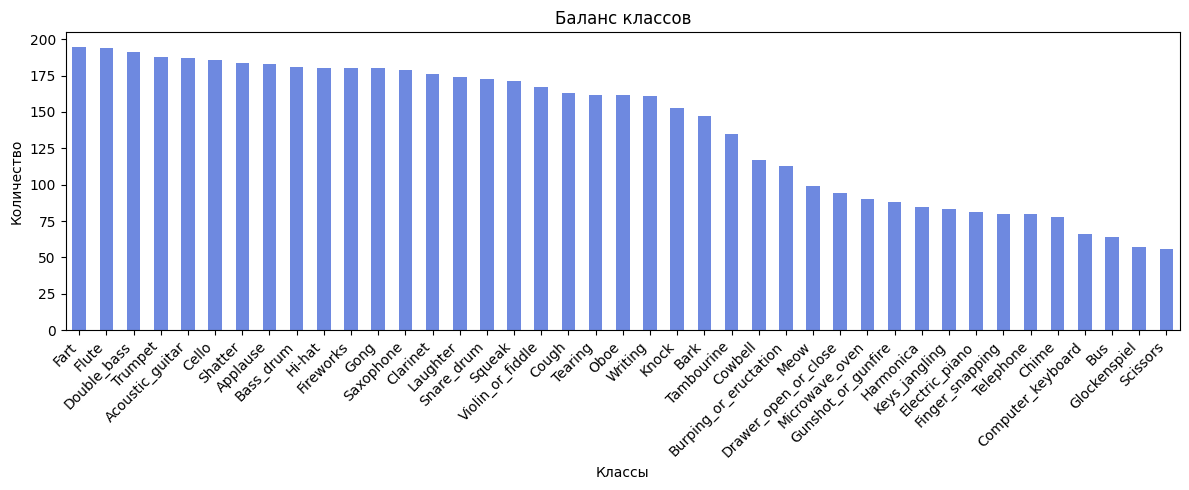

In [12]:
df['label'].value_counts().plot(kind='bar', figsize=(12,5), color = "#6E89E0")
plt.title('Баланс классов')
plt.xlabel('Классы')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
print(f"Размер датасета: {df.shape}")
print(f"Количество уникальных классов: {df['label'].nunique()}")

Размер датасета: (5683, 2)
Количество уникальных классов: 41


## Функция для извлечения признаков


In [53]:
def extract_features(file_path, 
                    n_mfcc=13,
                    use_windowing=True,
                    window_duration=0.25,
                    window_overlap=0.5,
                    window_function='hamming',
                    stats=['mean', 'std', 'min', 'max'],
                    **kwargs):
    
    audio, sr = librosa.load(file_path, sr=None)
    
    # Оконные функции
    window_funcs = {
        'hamming': np.hamming,
        'hann': np.hanning,
        'blackman': np.blackman,
    }
    
    if not use_windowing:
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc, **kwargs)
        features = np.mean(mfccs, axis=1)  
        
    else:
        window_size = int(window_duration * sr)
        hop_length = int(window_size * (1 - window_overlap))
        
        windows = []
        for i in range(0, len(audio) - window_size + 1, hop_length):
            window = audio[i:i + window_size]
            
            if window_function in window_funcs:
                window = window * window_funcs[window_function](window_size)
            elif callable(window_function):
                window = window * window_function(window_size)
            
            windows.append(window)
        
        # Для каждого окна MFCC
        window_features = []
        for window in windows:
            mfccs = librosa.feature.mfcc(y=window, sr=sr, n_mfcc=n_mfcc, **kwargs)
            window_features.append(np.mean(mfccs, axis=1))
        
        window_features = np.array(window_features)
        
        # Статистики
        stats_functions = {
            'mean': np.mean,
            'std': np.std,
            'min': np.min,
            'max': np.max,
            'median': np.median,
            'var': np.var
        }
        
        features_list = []
        for stat in stats:
            if stat in stats_functions:
                features_list.append(stats_functions[stat](window_features, axis=0))
        
        features = np.concatenate(features_list) if features_list else np.array([])
    
    return features

In [ ]:
# Функция для запуска эксперимента

def run_experiment(X, y, model, model_name=None, hyperparams=False, test_size=0.2, random_state=42, scale_data=True):
    
    X = np.array(X)
    y = np.array(y)
    
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=random_state, stratify=y_encoded
    )
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    if hyperparams:
        unique, counts = np.unique(y, return_counts=True)
        priors = counts / len(y)

        param_grid = {
            'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3],
            'priors': [None, priors]
        }
        
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
        grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        print(f"Лучшие параметры: {grid_search.best_params_}")
        
        model = grid_search.best_estimator_


    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    if model_name is None:
        model_name = type(model).__name__
    
    # Считаем метрики
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    f1_m = f1_score(y_test, y_pred, average='macro')
    
    print(f"\nClassification results:\n")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 weighted: {f1_w:.3f}")
    print(f"F1 macro: {f1_m:.3f}")
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Предсказанные метки")
    plt.ylabel("Истинные метки")
    plt.title(f"Матрица ошибок ({model_name})")
    plt.show()
    
    return {'model_name': model_name, 'accuracy': acc, 'f1_weighted': f1_w, 'f1_macro': f1_m}

## Эксперимент 1
- 13-мерные mfcc
- Naive Bayes в чистом виде

In [ ]:
# 13 mfcc
X, y = [], []
for _, row in df.iterrows():
    file_path = os.path.join(audio_dir, row['fname'])

    X.append(extract_features(file_path, use_windowing=False))
    y.append(row['label'])


Classification results:

Accuracy: 0.321
F1 weighted: 0.303
F1 macro: 0.302


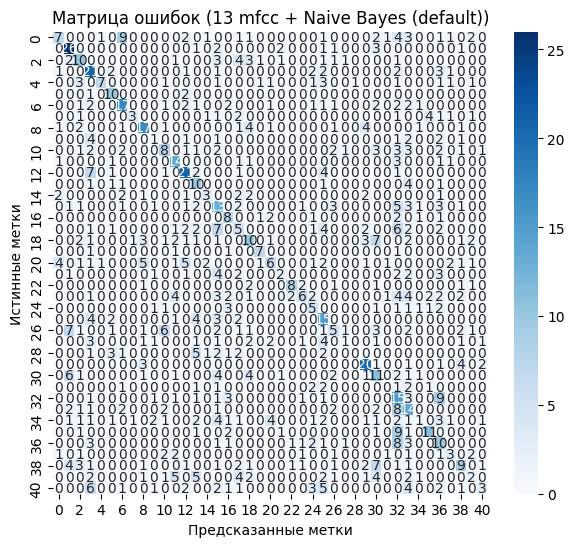

In [27]:
results = []
results.append(run_experiment(X, y, GaussianNB(), model_name="13 mfcc + Naive Bayes (default)"))

In [ ]:
# 40 mfcc
X, y = [], []
for _, row in df.iterrows():
    file_path = os.path.join(audio_dir, row['fname'])

    X.append(extract_features(file_path, n_mfcc = 40, use_windowing=False))
    y.append(row['label'])


Classification results:

Accuracy: 0.295
F1 weighted: 0.285
F1 macro: 0.274


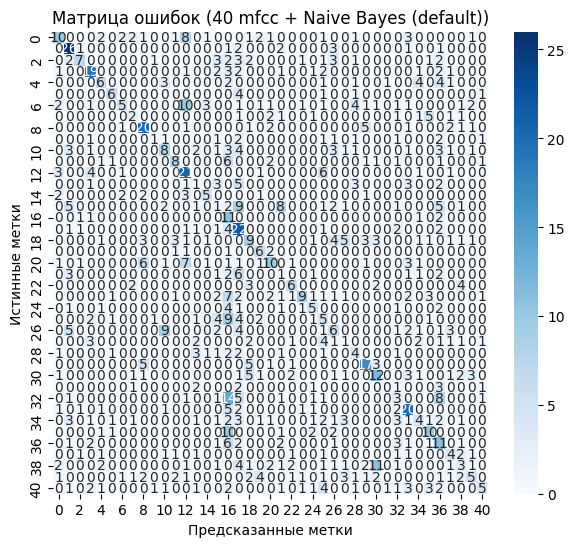

In [30]:
results.append(run_experiment(X, y, GaussianNB(), model_name="40 mfcc + Naive Bayes (default)"))

#### С увеличением n_mfcc точность падает

## Эксперимент 2
- 13-мерные mfcc
- применение окнных функций
- Naive Bayes в чистом виде

In [ ]:
# 13 mfcc + окна Хэмминга
X, y = [], []
for _, row in df.iterrows():
    file_path = os.path.join(audio_dir, row['fname'])

    X.append(extract_features(file_path, use_windowing=True, window_duration=0.25, window_overlap=0.5, window_function='hamming'))
    y.append(row['label'])


Classification results:

Accuracy: 0.398
F1 weighted: 0.389
F1 macro: 0.386


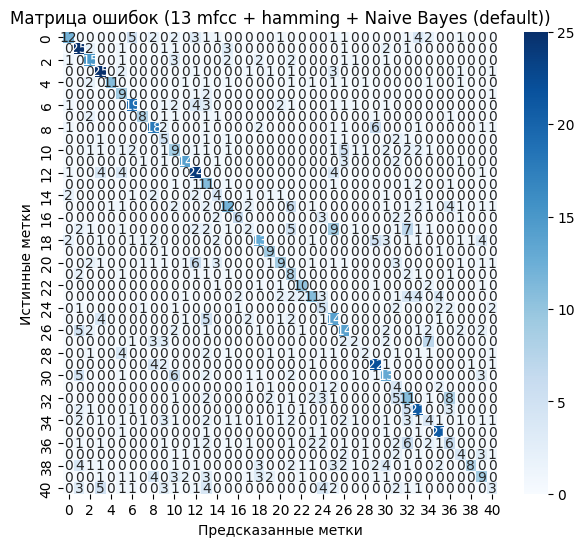

In [33]:
results.append(run_experiment(X, y, GaussianNB(), model_name="13 mfcc + hamming + Naive Bayes (default)"))

In [ ]:
# 13 mfcc + окна Haan
X, y = [], []
for _, row in df.iterrows():
    file_path = os.path.join(audio_dir, row['fname'])
    
    X.append(extract_features(file_path, use_windowing=True, window_duration=0.25, window_overlap=0.5, window_function='hann'))
    y.append(row['label'])


Classification results:

Accuracy: 0.389
F1 weighted: 0.378
F1 macro: 0.377


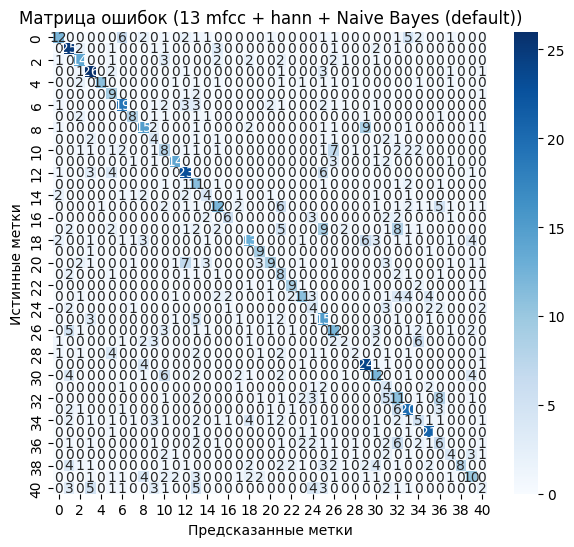

In [36]:
results.append(run_experiment(X, y, GaussianNB(), model_name="13 mfcc + hann + Naive Bayes (default)"))

In [ ]:
# 13 mfcc + окна Блэкмана
X, y = [], []
for _, row in df.iterrows():
    file_path = os.path.join(audio_dir, row['fname'])
    
    X.append(extract_features(file_path, use_windowing=True, window_duration=0.25, window_overlap=0.5, window_function='blackman'))
    y.append(row['label'])


Classification results:

Accuracy: 0.388
F1 weighted: 0.377
F1 macro: 0.376


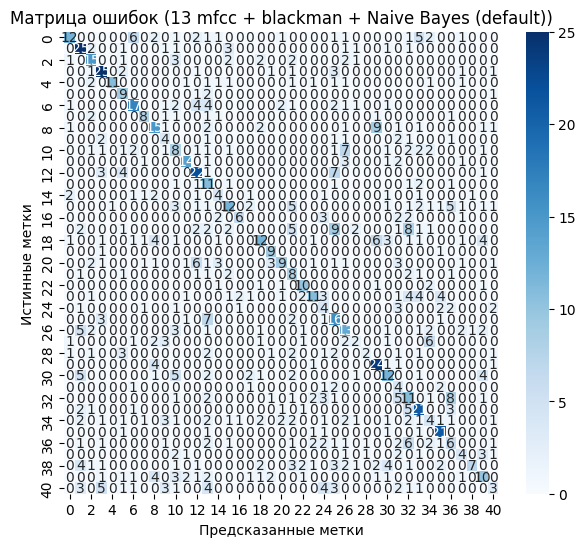

In [39]:
results.append(run_experiment(X, y, GaussianNB(), model_name="13 mfcc + blackman + Naive Bayes (default)"))

#### Лучший результат на окне Хэмминга

## Эксперимент 3
- 13-мерные mfcc по окнам
- Окна Хэмминга
- Naive Bayes с подбором параметров

In [ ]:
# 13 mfcc + окна Хэмминга
X, y = [], []
for _, row in df.iterrows():
    file_path = os.path.join(audio_dir, row['fname'])
    
    X.append(extract_features(file_path, use_windowing=True, window_duration=0.25, window_overlap=0.5, window_function='hamming'))
    y.append(row['label'])

Лучшие параметры: {'priors': None, 'var_smoothing': 0.0001}

Classification results:

Accuracy: 0.398
F1 weighted: 0.389
F1 macro: 0.386


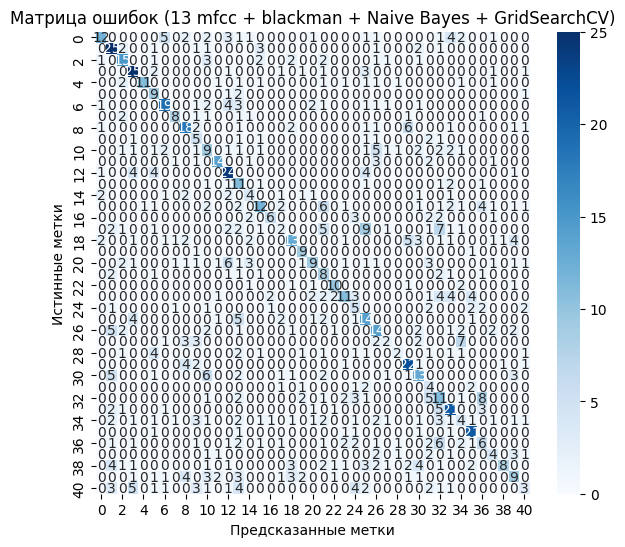

In [48]:
results.append(run_experiment(X, y, GaussianNB(), hyperparams=True, model_name="13 mfcc + blackman + Naive Bayes + GridSearchCV"))

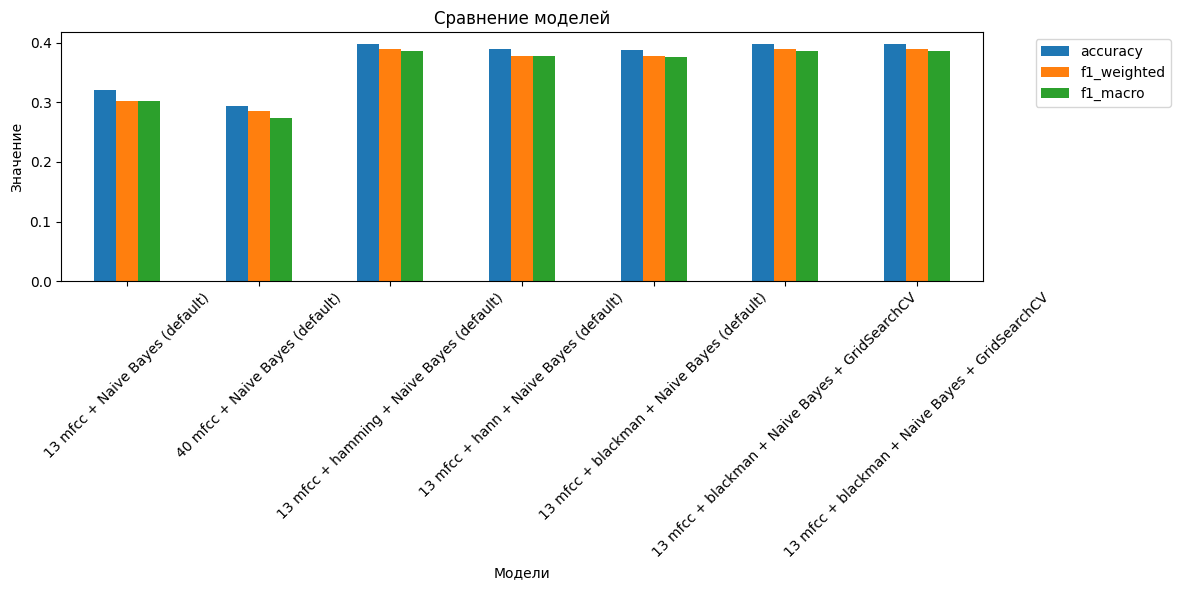

In [51]:
df_results = pd.DataFrame(results)

df_results.plot(x='model_name', y=['accuracy', 'f1_weighted', 'f1_macro'], kind='bar', figsize=(12, 6))
plt.title('Сравнение моделей')
plt.xlabel('Модели')
plt.ylabel('Значение')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Выводы
- #### После провендения ряда экспериментов на различном количестве признаков mfcc (13, 40), с тремя типами оконных функций (haan, hamming, blackman) наилучший результат (Acc = 0.398, F1_w = 0.389, F1_m = 0.386) был достигнут при кобинации 13 признаков mfcc и окна Хэмминга. 
- #### Подбор гиперпараметров по сетке не изменил результата
- #### Модель Naive Bayes плохо справляется с данной задачей